# #01 Figures

In [6]:
import os
import sys

ROOT_DIR = os.path.normpath(os.path.join(os.getcwd(), "..", "..", ".."))
if ROOT_DIR not in sys.path:
    sys.path.insert(0, ROOT_DIR)

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [ ]:
plt.rcParams.update({
    "text.usetex"    : False,
    "font.family"    : "serif",
    "font.size"      : 11,
    "axes.titlesize" : 12,
    "figure.dpi"     : 150,
    "savefig.dpi"    : 150,
})

In [10]:
# ── 텍스트 크기 ──────────────────────────────────────────────
FS_LABEL = 9     # 축 레이블: "Real", "Imaginary"
FS_TICK  = 9     # 눈금 레이블
FS_ZERO  = 9     # zeros 레이블 (Fig 1)
FS_CURVE = 10    # 곡선 레이블 (Fig 3)

# ── 마커 크기 ────────────────────────────────────────────────
MS_ARROW  = 4    # 축 화살표 마커
MS_TRIVIAL = 6   # trivial zeros 마커 (Fig 1)
MS_NONTRIVIAL = 6 # nontrivial zeros 마커 (Fig 1)
MS_POLE   = 5    # pole 열린 원 마커 (Fig 1)

# ── 선 두께 ──────────────────────────────────────────────────
LW_AXIS  = 1.2   # 축 선 두께 (Fig 1)
LW_STRIP = 0.8   # critical strip 경계선
LW_CURVE = 1.5   # 곡선 sin x, P_N(x) (Fig 3)
LW_TICK  = 0.7   # 눈금 선

## Figure 1. 복소평면에서 $\zeta(s)$의 zeros 분포

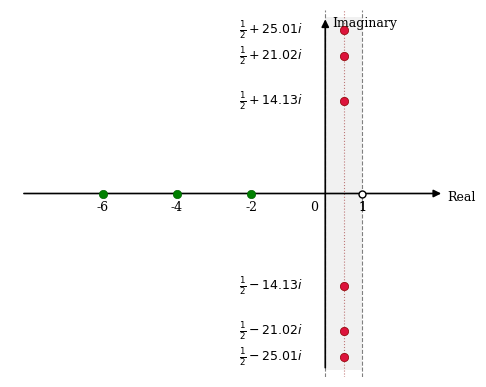

In [24]:
fig, ax = plt.subplots(figsize=(5, 4))

# 축 설정
ax.set_xlim(-8.5, 3.5)
ax.set_ylim(-28, 28)
ax.axis("off")

# 복소평면 축 (화살표)
ax.annotate("", xy=(3.2, 0), xytext=(-8.2, 0),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=LW_AXIS))
ax.annotate("", xy=(0, 27), xytext=(0, -27),
            arrowprops=dict(arrowstyle="-|>", color="black", lw=LW_AXIS))

# 축 레이블
ax.text(3.3,  -1.2, "Real",      fontsize=FS_LABEL, ha="left")
ax.text(0.2,   27,  "Imaginary", fontsize=FS_LABEL, ha="left", va="top")

# 눈금 및 레이블 (Real 축)
real_ticks = [-6, -4, -2, 0, 1]
for x in real_ticks:
    ax.plot([x, x], [-0.3, 0.3], color="black", lw=LW_TICK)
    if x != 0:
        ax.text(x, -1.2, str(x), ha="center", va="top", fontsize=FS_TICK)
    else:
        ax.text(x - 0.3, -1.2, "0", ha="center", va="top", fontsize=FS_TICK)

ax.text(1, -1.2, "1", ha="center", va="top", fontsize=FS_TICK)

# Critical strip 음영 (0 < Re(s) < 1)
strip = patches.Rectangle(
    (0, -27), 1, 54,
    linewidth=0, facecolor="lightgray", alpha=0.3, zorder=0
)
ax.add_patch(strip)

# Critical strip 경계선
ax.axvline(x=0,   color="gray",    lw=LW_STRIP, linestyle="--", zorder=1)
ax.axvline(x=1,   color="gray",    lw=LW_STRIP, linestyle="--", zorder=1)
ax.axvline(x=0.5, color="darkred", lw=LW_STRIP, linestyle=":",
           alpha=0.5, zorder=1)

# Trivial zeros (녹색)
trivial_zeros = [-2, -4, -6]
for x in trivial_zeros:
    ax.plot(x, 0, "o",
            color="green", markersize=MS_TRIVIAL,
            markeredgecolor="darkgreen", markeredgewidth=0.5, zorder=3)

# Nontrivial zeros (적색)
nontrivial_im = [14.13, 21.02, 25.01]
for im in nontrivial_im:
    for sign in [1, -1]:
        ax.plot(0.5, sign * im, "o",
                color="crimson", markersize=MS_NONTRIVIAL,
                markeredgecolor="darkred", markeredgewidth=0.5, zorder=3)

# Nontrivial zeros 레이블
label_x = -0.6
for im in nontrivial_im:
    ax.text(label_x,  im,
            r"$\frac{1}{2} + " + f"{im}" + r"i$",
            ha="right", va="center", fontsize=FS_ZERO)
    ax.text(label_x, -im,
            r"$\frac{1}{2} - " + f"{im}" + r"i$",
            ha="right", va="center", fontsize=FS_ZERO)

# Pole at s=1 (열린 원)
ax.plot(1, 0, "o",
        color="white", markersize=MS_POLE,
        markeredgecolor="black", markeredgewidth=1.0, zorder=3)

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig(os.path.join("images", "fig-001-001.png"), bbox_inches="tight")
plt.show()

## Figure 2. Euler의 Basel problem 증명 구조

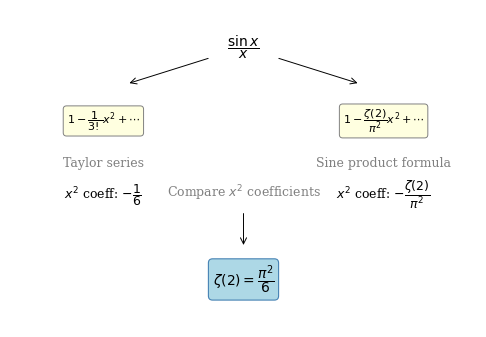

In [22]:
fig, ax = plt.subplots(figsize=(5, 3.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")

# ── 중앙 수식 sin x / x ─────────────────────────────────────
ax.text(5, 5.3, r"$\dfrac{\sin x}{x}$",
        ha="center", va="center", fontsize=10)

# ── 좌측 화살표 ──────────────────────────────────────────────
ax.annotate("", xy=(2.5, 4.6), xytext=(4.3, 5.1),
            arrowprops=dict(arrowstyle="->", color="black", lw=LW_TICK))

# ── 좌측 박스: Taylor series ─────────────────────────────────
ax.text(2, 3.9,
        r"$1 - \dfrac{1}{3!}x^2 + \cdots$",
        ha="center", va="center", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
                  edgecolor="gray", lw=0.7))
ax.text(2, 3.1, "Taylor series",
        ha="center", va="center", fontsize=FS_TICK, color="gray")
ax.text(2, 2.5,
        r"$x^2$ coeff: $-\dfrac{1}{6}$",
        ha="center", va="center", fontsize=FS_TICK)

# ── 우측 화살표 ──────────────────────────────────────────────
ax.annotate("", xy=(7.5, 4.6), xytext=(5.7, 5.1),
            arrowprops=dict(arrowstyle="->", color="black", lw=LW_TICK))

# ── 우측 박스: Sine product formula ─────────────────────────
ax.text(8, 3.9,
        r"$1 - \dfrac{\zeta(2)}{\pi^2}x^2 + \cdots$",
        ha="center", va="center", fontsize=8,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
                  edgecolor="gray", lw=0.7))
ax.text(8, 3.1, "Sine product formula",
        ha="center", va="center", fontsize=FS_TICK, color="gray")
ax.text(8, 2.5,
        r"$x^2$ coeff: $-\dfrac{\zeta(2)}{\pi^2}$",
        ha="center", va="center", fontsize=FS_TICK)

# ── 하단 화살표 및 결론 ──────────────────────────────────────
ax.annotate("", xy=(5, 1.5), xytext=(5, 2.2),
            arrowprops=dict(arrowstyle="->", color="black", lw=LW_TICK))
ax.text(5, 2.35, "Compare $x^2$ coefficients",
        ha="center", va="bottom", fontsize=FS_TICK, color="gray")
ax.text(5, 0.9,
        r"$\zeta(2) = \dfrac{\pi^2}{6}$",
        ha="center", va="center", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue",
                  edgecolor="steelblue", lw=0.8))

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig(os.path.join("images", "fig-001-002.png"), bbox_inches="tight")
plt.show()

## Figure 3. Sine product formula 유한 항 근사와 $\sin x$의 비교

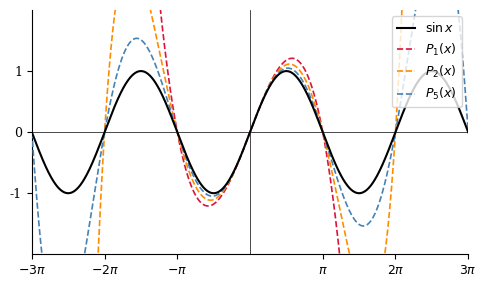

In [23]:
x = np.linspace(-3 * np.pi, 3 * np.pi, 1000)

fig, ax = plt.subplots(figsize=(5, 3))

# ── sin x ────────────────────────────────────────────────────
ax.plot(x, np.sin(x),
        color="black", lw=LW_CURVE, label=r"$\sin x$", zorder=4)

# ── P_N(x) for N = 1, 2, 5 ──────────────────────────────────
N_values = [1, 2, 5]
colors   = ["crimson", "darkorange", "steelblue"]

for N, color in zip(N_values, colors):
    P = x.copy()
    for n in range(1, N + 1):
        P = P * (1 - x**2 / (n**2 * np.pi**2))
    ax.plot(x, P, color=color, lw=LW_CURVE * 0.8,
            linestyle="--", label=f"$P_{{{N}}}(x)$", zorder=3)

# ── 축 설정 ─────────────────────────────────────────────────
ax.set_xlim(-3 * np.pi, 3 * np.pi)
ax.set_ylim(-2.0, 2.0)
ax.axhline(0, color="black", lw=0.5)
ax.axvline(0, color="black", lw=0.5)

# x축 눈금 (±π, ±2π, ±3π)
pi_ticks = [-3, -2, -1, 1, 2, 3]
pi_labels = [r"$-3\pi$", r"$-2\pi$", r"$-\pi$",
             r"$\pi$",   r"$2\pi$",  r"$3\pi$"]
ax.set_xticks([n * np.pi for n in pi_ticks])
ax.set_xticklabels(pi_labels, fontsize=FS_TICK)
ax.set_yticks([-1, 0, 1])
ax.set_yticklabels(["-1", "0", "1"], fontsize=FS_TICK)

ax.legend(fontsize=FS_TICK, loc="upper right",
          framealpha=0.8, handlelength=1.5)

ax.spines["right"].set_visible(False)
ax.spines["top"].set_visible(False)

plt.tight_layout()
os.makedirs("images", exist_ok=True)
plt.savefig(os.path.join("images", "fig-001-003.png"), bbox_inches="tight")
plt.show()